✅ DEM + OBJ saved in:
G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_50_Moss_0_Lichen_0


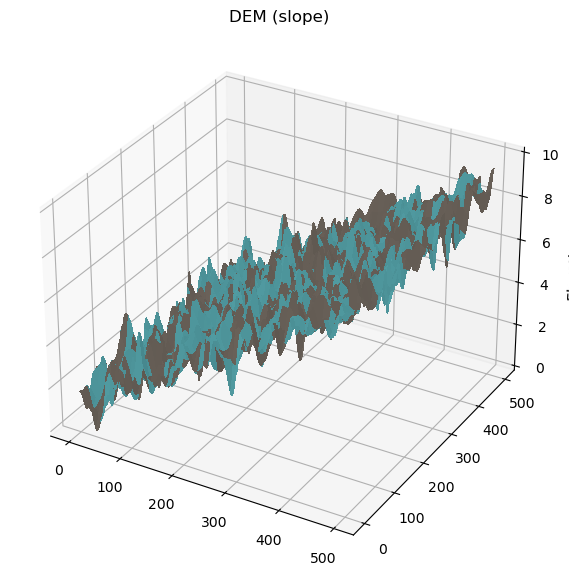

In [54]:
from pathlib import Path
import csv, json
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

# ===================== USER SETTINGS =====================
BASE_DIR = Path(r"G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_50_Moss_0_Lichen_0")

# Either a grid (lc_map.csv) or triplets (landcover_table.csv); the loader will auto-detect.
LANDCOVER_CSV = BASE_DIR / "lc_map.csv"
OBJ_NAME = "Slope_Mild_Snow_0_Algae_50_Moss_0_Lichen_0_synthetic_dem.obj"

# DEM controls
USE_SLOPE = True          # False => flat plane
BASE_ELEV = 0.0
MAX_ALT_DIFF = 10.0
SLOPE_FRACTION = 0.8
NOISE_AMPLITUDE = 0.5      # <<< set to 0 for plain ground
SMOOTH_SIGMA = 6
RESCALE_TO_MAX = True
SEED = 43
# =========================================================

CLASS_NAMES = {0:"snow",1:"rock",2:"moss",3:"algae",4:"lichen"}
PALETTE = {0:(1,1,1),1:(0.51,0.47,0.43),2:(0.20,0.63,0.31),3:(0.39,0.75,0.78),4:(0.78,0.71,0.24)}

# ---------------- Robust Landcover Loader ----------------
def load_landcover(path: Path) -> np.ndarray:
    """
    Auto-detect landcover CSV format:
      - GRID: many columns (square/rectangular), each cell is a class id
      - TRIPLETS: rows of x,y,class (header allowed)
    Returns uint8 2D array of class ids.
    """
    import pandas as pd
    try:
        df = pd.read_csv(path, header=None)
    except Exception:
        # fallback to python csv
        return _read_triplets(path)

    # Heuristic: if columns > 3 or it's "wide", treat as GRID
    if df.shape[1] > 3:
        arr = df.values.astype(np.uint8)
        return arr
    # If exactly 3 columns and looks like integers → TRIPLETS
    if df.shape[1] == 3:
        # Check if it’s actually a header; if so, re-read with header=0
        if not np.issubdtype(df.iloc[0,0].__class__, (int, float)):
            df = pd.read_csv(path)  # with header
            if df.shape[1] != 3:
                raise ValueError("Triplets CSV must have exactly 3 columns (x,y,class).")
        xs = df.iloc[:,0].astype(int).to_numpy()
        ys = df.iloc[:,1].astype(int).to_numpy()
        ts = df.iloc[:,2].astype(int).to_numpy()
        h, w = ys.max()+1, xs.max()+1
        land = np.full((h, w), 1, dtype=np.uint8)
        land[ys, xs] = ts.astype(np.uint8)
        return land

    # Fallback: parse as triplets with csv
    return _read_triplets(path)

def _read_triplets(path: Path) -> np.ndarray:
    xs, ys, ts = [], [], []
    with open(path, newline="") as f:
        rdr = csv.reader(f)
        first = next(rdr, None)
        # Skip header if non-numeric
        def _isnum(s):
            try: float(s); return True
            except: return False
        if first and _isnum(first[0]) and _isnum(first[1]) and _isnum(first[2]):
            xs.append(int(float(first[0]))); ys.append(int(float(first[1]))); ts.append(int(float(first[2])))
        for row in rdr:
            if len(row) < 3: continue
            xs.append(int(float(row[0]))); ys.append(int(float(row[1]))); ts.append(int(float(row[2])))
    h, w = max(ys)+1, max(xs)+1
    land = np.full((h, w), 1, dtype=np.uint8)
    land[ys, xs] = np.array(ts, dtype=np.uint8)
    return land

# ---------------- DEM Generator ----------------
def generate_dem(land, use_slope, base_elev, max_alt_diff, slope_fraction,
                 noise_amplitude, smooth_sigma, rescale, seed):
    ny, nx = land.shape
    rng = np.random.default_rng(seed)
    dem = np.full((ny,nx), base_elev, float)

    if use_slope:
        sx = np.linspace(0, max_alt_diff*slope_fraction, nx)
        dem += np.add.outer(np.zeros(ny), sx)

    if noise_amplitude > 0:
        noise = rng.random((ny,nx)) - 0.5
        if smooth_sigma > 0:
            noise = gaussian_filter(noise, smooth_sigma)
        # normalize to [-0.5, 0.5]
        nmin, nmax = noise.min(), noise.max()
        if nmax > nmin:
            noise = (noise - nmin) / (nmax - nmin) - 0.5
        dem += noise * max_alt_diff * noise_amplitude

    if rescale:
        mn, mx = dem.min(), dem.max()
        if mx > mn:
            dem = (dem - mn) / (mx - mn) * max_alt_diff + base_elev
        else:
            dem[:] = base_elev  # perfectly flat
    return dem

# ---------------- OBJ Export ----------------
def write_obj(land, dem, out_path):
    rows, cols = land.shape
    with out_path.open("w") as f:
        f.write("# Synthetic DEM OBJ\n")
        for i in range(rows):
            for j in range(cols):
                f.write(f"v {j} {dem[i,j]:.6f} {i}\n")
        for cls in [0,2,3,4,1]:
            f.write(f"g {CLASS_NAMES.get(cls, cls)}\n")
            for i in range(rows-1):
                for j in range(cols-1):
                    if land[i,j] != cls: continue
                    v0=i*cols+j+1; v1=v0+1; v2=v0+cols; v3=v2+1
                    f.write(f"f {v0} {v2} {v3}\n")
                    f.write(f"f {v0} {v3} {v1}\n")

# ---------------- Preview ----------------
def show_dem_3d(land, dem):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    ny,nx = land.shape
    X,Y=np.meshgrid(range(nx),range(ny))
    rgb=np.zeros((ny,nx,3))
    for c,clr in PALETTE.items(): rgb[land==c]=clr
    fig=plt.figure(figsize=(10,7))
    ax=fig.add_subplot(111,projection="3d")
    ax.plot_surface(X,Y,dem,facecolors=rgb,linewidth=0,antialiased=False)
    ax.set_title(f"DEM ({'slope' if USE_SLOPE else 'flat'})")
    ax.set_zlabel("Elevation (m)")
    plt.show()

# ---------------- RUN ----------------
land = load_landcover(LANDCOVER_CSV)
dem = generate_dem(land, USE_SLOPE, BASE_ELEV, MAX_ALT_DIFF, SLOPE_FRACTION,
                   NOISE_AMPLITUDE, SMOOTH_SIGMA, RESCALE_TO_MAX, SEED)

# Assert flatness if expected
if not USE_SLOPE and NOISE_AMPLITUDE == 0.0:
    assert np.ptp(dem) == 0.0, "DEM is not flat—check parameters."

np.save(BASE_DIR / "dem.npy", dem)
Output = Path(r"C:\Users\hyou34\DART\user_data\simulations\Anttarctic_Vegetation_Dynamic\DART\Simulations\TableA\PureAlgae\input")
write_obj(land, dem, Output / OBJ_NAME)
print(f"✅ DEM + OBJ saved in:\n{BASE_DIR}")

show_dem_3d(land, dem)


## Standard Slope DEM

✅ Outputs written:
   - DEM (npy): G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableB\Snow_0_Algae_0_Moss_50_Lichen_0\dem.npy
   - OBJ:       C:\Users\hyou34\DART\user_data\simulations\Anttarctic Vegetation Dynamic\DART\Simulations\TableB\input\Slope15_Snow_0_Algae_0_Moss_50_Lichen_0_synthetic_dem.obj


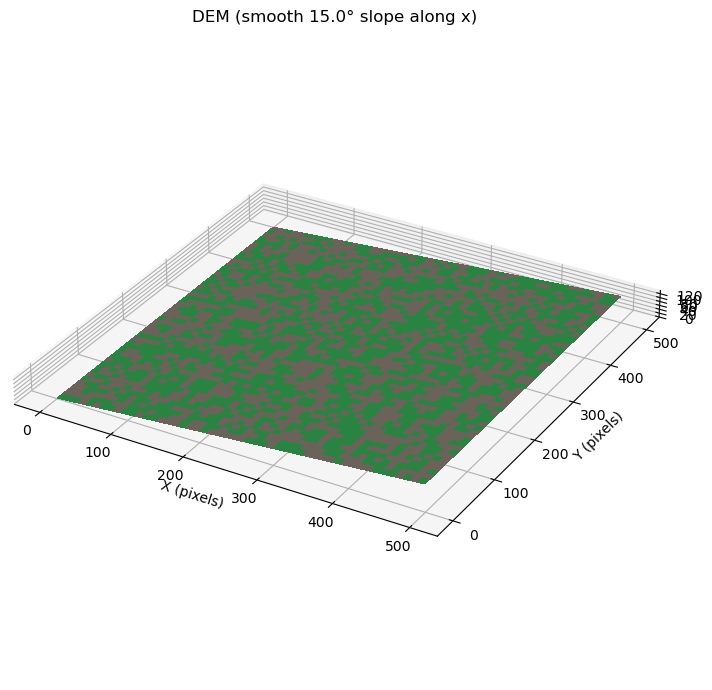

In [107]:
from pathlib import Path
import csv
import numpy as np
from scipy.ndimage import gaussian_filter  # not used in the angle version, but kept if you later switch back
import matplotlib.pyplot as plt

# ===================== USER SETTINGS =====================
# Base folder where your landcover CSV lives and where dem.npy will be saved
BASE_DIR = Path(r"G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableB\Snow_0_Algae_0_Moss_50_Lichen_0")

# Either a grid (lc_map.csv) or triplets (landcover_table.csv); the loader will auto-detect.
LANDCOVER_CSV = BASE_DIR / "lc_map.csv"

# Output OBJ file name (will be written to Output folder below)
OBJ_NAME = "Slope15_Snow_0_Algae_0_Moss_50_Lichen_0_synthetic_dem.obj"

# DEM controls (angle-based smooth plane)
BASE_ELEV = 0.0          # elevation offset for the whole surface
SLOPE_ANGLE_DEG = 15.0   # exact slope angle in degrees
SLOPE_AXIS = "x"         # 'x' => increasing to the right; 'y' => increasing upward
PIXEL_SIZE = 1.0         # horizontal size of each pixel in OBJ units (e.g., 1 = one grid cell per unit)

# Preview controls
SHOW_3D = True

# OBJ output directory
Output = Path(r"C:\Users\hyou34\DART\user_data\simulations\Anttarctic Vegetation Dynamic\DART\Simulations\TableB\input")
# =========================================================

# Class dictionary and simple colors used for preview (RGB 0-1)
CLASS_NAMES = {0: "snow", 1: "rock", 2: "moss", 3: "algae", 4: "lichen"}
PALETTE = {
    0: (1.00, 1.00, 1.00),  # snow - white
    1: (0.51, 0.47, 0.43),  # rock - brown/gray
    2: (0.20, 0.63, 0.31),  # moss - green
    3: (0.39, 0.75, 0.78),  # algae - cyan
    4: (0.78, 0.71, 0.24),  # lichen - yellow
}

# ---------------- Robust Landcover Loader ----------------
def load_landcover(path: Path) -> np.ndarray:
    """
    Auto-detect landcover CSV format:
      - GRID: many columns (square/rectangular), each cell is a class id
      - TRIPLETS: rows of x,y,class (header allowed)
    Returns: uint8 2D array of class ids.
    """
    import pandas as pd

    # Try fast load with pandas
    try:
        df = pd.read_csv(path, header=None)
    except Exception:
        # Fallback parser for triplets
        return _read_triplets(path)

    # Heuristic: If there are more than 3 columns, this is a grid CSV
    if df.shape[1] > 3:
        arr = df.values.astype(np.uint8)
        return arr

    # If exactly 3 columns, treat as triplets (possibly with a header)
    if df.shape[1] == 3:
        # If the first row is non-numeric, re-read with header so columns can be named
        def _is_number(x):
            try:
                float(x)
                return True
            except Exception:
                return False

        first_row = df.iloc[0].tolist()
        if not all(_is_number(v) for v in first_row):
            df = pd.read_csv(path)  # with header row
            if df.shape[1] != 3:
                raise ValueError("Triplets CSV must have exactly 3 columns (x,y,class).")

        xs = df.iloc[:, 0].astype(int).to_numpy()
        ys = df.iloc[:, 1].astype(int).to_numpy()
        ts = df.iloc[:, 2].astype(int).to_numpy()

        h, w = ys.max() + 1, xs.max() + 1
        land = np.full((h, w), 1, dtype=np.uint8)  # default to 'rock' if missing
        land[ys, xs] = ts.astype(np.uint8)
        return land

    # Last resort: try the manual triplet reader
    return _read_triplets(path)


def _read_triplets(path: Path) -> np.ndarray:
    """
    Manual CSV loader for x,y,class triplets with optional header.
    """
    xs, ys, ts = [], [], []

    def _isnum(s):
        try:
            float(s)
            return True
        except Exception:
            return False

    with open(path, newline="") as f:
        rdr = csv.reader(f)
        first = next(rdr, None)
        # If the first row is numeric triplet, treat it as data; otherwise skip as header
        if first and len(first) >= 3 and _isnum(first[0]) and _isnum(first[1]) and _isnum(first[2]):
            xs.append(int(float(first[0])))
            ys.append(int(float(first[1])))
            ts.append(int(float(first[2])))

        for row in rdr:
            if len(row) < 3:
                continue
            xs.append(int(float(row[0])))
            ys.append(int(float(row[1])))
            ts.append(int(float(row[2])))

    h, w = max(ys) + 1, max(xs) + 1
    land = np.full((h, w), 1, dtype=np.uint8)  # default 'rock'
    land[ys, xs] = np.array(ts, dtype=np.uint8)
    return land


# ---------------- DEM Generator (Angle-based smooth plane) ----------------
def generate_dem_angle(land: np.ndarray, base_elev: float, angle_deg: float, axis: str = "x", pixel_size: float = 1.0) -> np.ndarray:
    """
    Generate a perfectly smooth planar DEM with a precise slope angle.

    Parameters
    ----------
    land : np.ndarray
        2D int array (H, W) of class IDs; only its shape is used here.
    base_elev : float
        Elevation offset added to the whole surface.
    angle_deg : float
        Target slope angle in degrees (e.g., 15.0).
    axis : str
        'x' => slope increases along columns (left->right).
        'y' => slope increases along rows (top->bottom).
    pixel_size : float
        Horizontal spacing between pixels in OBJ units. If each pixel is 1 m, set 1.0.

    Returns
    -------
    dem : np.ndarray
        Float DEM with shape (H, W), planar and ripple-free.
    """
    ny, nx = land.shape
    theta = np.deg2rad(angle_deg)
    # Elevation increment per pixel step along the slope axis
    step = np.tan(theta) * pixel_size

    if axis.lower() == "x":
        x = np.arange(nx, dtype=float)
        dem = base_elev + np.add.outer(np.zeros(ny, dtype=float), x * step)
    elif axis.lower() == "y":
        y = np.arange(ny, dtype=float)
        dem = base_elev + np.add.outer(y * step, np.zeros(nx, dtype=float))
    else:
        raise ValueError("axis must be 'x' or 'y'")
    return dem


# ---------------- OBJ Export ----------------
def write_obj(land: np.ndarray, dem: np.ndarray, out_path: Path):
    """
    Export a very simple OBJ:
      - Vertices laid on a regular grid: v x y z  (x=j, y=dem, z=i)
      - Faces only where the cell class matches the active group (two triangles per pixel)
      - Groups are written in the order: snow, moss, algae, lichen, rock (so rock is last)
    """
    rows, cols = land.shape
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with out_path.open("w") as f:
        f.write("# Synthetic DEM OBJ (smooth plane)\n")
        # Write vertices
        for i in range(rows):
            for j in range(cols):
                f.write(f"v {j} {dem[i, j]:.6f} {i}\n")

        # Write faces grouped by class for simple material assignment later if needed
        for cls in [0, 2, 3, 4, 1]:  # snow, moss, algae, lichen, rock
            f.write(f"g {CLASS_NAMES.get(cls, str(cls))}\n")
            for i in range(rows - 1):
                for j in range(cols - 1):
                    if land[i, j] != cls:
                        continue
                    v0 = i * cols + j + 1
                    v1 = v0 + 1
                    v2 = v0 + cols
                    v3 = v2 + 1
                    f.write(f"f {v0} {v2} {v3}\n")
                    f.write(f"f {v0} {v3} {v1}\n")


# ---------------- Preview ----------------
def show_dem_3d(land: np.ndarray, dem: np.ndarray, title: str = "DEM (smooth 15° slope)"):
    """
    Quick 3D preview using matplotlib. Colors are by landcover class.
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    ny, nx = land.shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))

    # Build RGB texture by class
    rgb = np.zeros((ny, nx, 3), dtype=float)
    for c, clr in PALETTE.items():
        rgb[land == c] = clr

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, dem, facecolors=rgb, linewidth=0, antialiased=False)
    ax.set_title(title)
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    ax.set_zlabel("Elevation")
    # Make Z a bit tighter so slope is visible
    ax.set_box_aspect((nx, ny, max(1, (dem.max() - dem.min()) * 0.25)))
    plt.tight_layout()
    plt.show()


# ---------------- RUN ----------------
if __name__ == "__main__":
    # 1) Load landcover (auto-detect grid vs triplets)
    land = load_landcover(LANDCOVER_CSV)

    # 2) Generate a perfectly smooth plane with an exact 15° slope
    dem = generate_dem_angle(
        land=land,
        base_elev=BASE_ELEV,
        angle_deg=SLOPE_ANGLE_DEG,
        axis=SLOPE_AXIS,
        pixel_size=PIXEL_SIZE,
    )

    # 3) Save outputs
    BASE_DIR.mkdir(parents=True, exist_ok=True)
    np.save(BASE_DIR / "dem.npy", dem)

    Output.mkdir(parents=True, exist_ok=True)
    write_obj(land, dem, Output / OBJ_NAME)
    print("✅ Outputs written:")
    print(f"   - DEM (npy): {BASE_DIR / 'dem.npy'}")
    print(f"   - OBJ:       {Output / OBJ_NAME}")

    # 4) Preview (optional)
    if SHOW_3D:
        title = f"DEM (smooth {SLOPE_ANGLE_DEG:.1f}° slope along {SLOPE_AXIS})"
        show_dem_3d(land, dem, title=title)


## Flat DEM

✅ Outputs written:
   - DEM (npy): G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableB\Snow_28_Algae_65_Moss_0_Lichen_0\dem.npy
   - OBJ:       C:\Users\hyou34\DART\user_data\simulations\Anttarctic Vegetation Dynamic\DART\Simulations\TableB\input\Snow_28_Algae_65_Moss_0_Lichen_0_synthetic_dem.obj


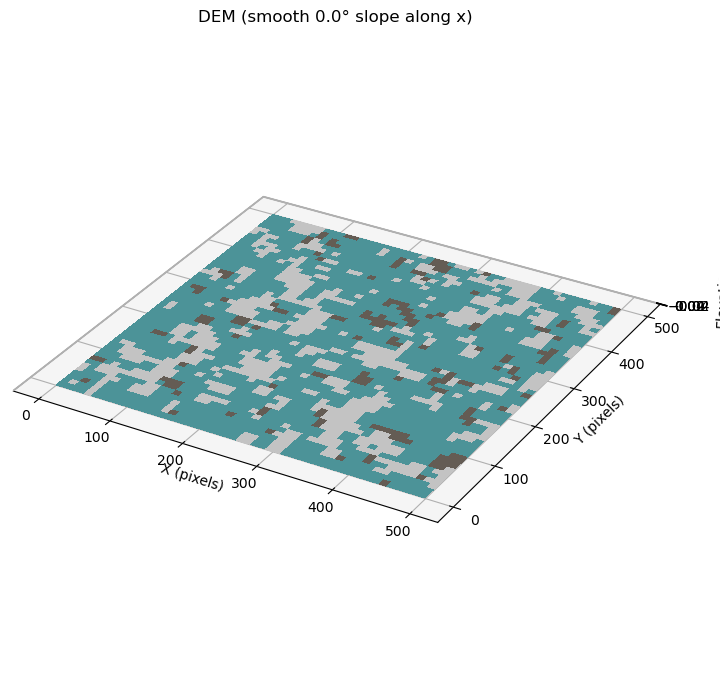

In [244]:
from pathlib import Path
import csv
import numpy as np
from scipy.ndimage import gaussian_filter  # not used in the angle version, but kept if you later switch back
import matplotlib.pyplot as plt

# ===================== USER SETTINGS =====================
# Base folder where your landcover CSV lives and where dem.npy will be saved
SCENARIO_NAME = "Snow_0_Algae_65_Moss_0_Lichen_0"

BASE_DIR = Path(
    r"G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover"
    fr"\TableB\{SCENARIO_NAME}"
)
# Input CSV (either lc_map.csv or landcover_table.csv)
LANDCOVER_CSV = BASE_DIR / "lc_map.csv"

# Output OBJ file
OBJ_NAME = f"{SCENARIO_NAME}_synthetic_dem.obj"

# DEM controls (angle-based smooth plane)
BASE_ELEV = 0.0          # elevation offset for the whole surface
SLOPE_ANGLE_DEG = 0.0   # exact slope angle in degrees
SLOPE_AXIS = "x"         # 'x' => increasing to the right; 'y' => increasing upward
PIXEL_SIZE = 1.0         # horizontal size of each pixel in OBJ units (e.g., 1 = one grid cell per unit)

# Preview controls
SHOW_3D = True

# OBJ output directory
Output = Path(r"C:\Users\hyou34\DART\user_data\simulations\Anttarctic Vegetation Dynamic\DART\Simulations\TableB\input")
# =========================================================

# Class dictionary and simple colors used for preview (RGB 0-1)
CLASS_NAMES = {0: "snow", 1: "rock", 2: "moss", 3: "algae", 4: "lichen"}
PALETTE = {
    0: (1.00, 1.00, 1.00),  # snow - white
    1: (0.51, 0.47, 0.43),  # rock - brown/gray
    2: (0.20, 0.63, 0.31),  # moss - green
    3: (0.39, 0.75, 0.78),  # algae - cyan
    4: (0.78, 0.71, 0.24),  # lichen - yellow
}

# ---------------- Robust Landcover Loader ----------------
def load_landcover(path: Path) -> np.ndarray:
    """
    Auto-detect landcover CSV format:
      - GRID: many columns (square/rectangular), each cell is a class id
      - TRIPLETS: rows of x,y,class (header allowed)
    Returns: uint8 2D array of class ids.
    """
    import pandas as pd

    # Try fast load with pandas
    try:
        df = pd.read_csv(path, header=None)
    except Exception:
        # Fallback parser for triplets
        return _read_triplets(path)

    # Heuristic: If there are more than 3 columns, this is a grid CSV
    if df.shape[1] > 3:
        arr = df.values.astype(np.uint8)
        return arr

    # If exactly 3 columns, treat as triplets (possibly with a header)
    if df.shape[1] == 3:
        # If the first row is non-numeric, re-read with header so columns can be named
        def _is_number(x):
            try:
                float(x)
                return True
            except Exception:
                return False

        first_row = df.iloc[0].tolist()
        if not all(_is_number(v) for v in first_row):
            df = pd.read_csv(path)  # with header row
            if df.shape[1] != 3:
                raise ValueError("Triplets CSV must have exactly 3 columns (x,y,class).")

        xs = df.iloc[:, 0].astype(int).to_numpy()
        ys = df.iloc[:, 1].astype(int).to_numpy()
        ts = df.iloc[:, 2].astype(int).to_numpy()

        h, w = ys.max() + 1, xs.max() + 1
        land = np.full((h, w), 1, dtype=np.uint8)  # default to 'rock' if missing
        land[ys, xs] = ts.astype(np.uint8)
        return land

    # Last resort: try the manual triplet reader
    return _read_triplets(path)


def _read_triplets(path: Path) -> np.ndarray:
    """
    Manual CSV loader for x,y,class triplets with optional header.
    """
    xs, ys, ts = [], [], []

    def _isnum(s):
        try:
            float(s)
            return True
        except Exception:
            return False

    with open(path, newline="") as f:
        rdr = csv.reader(f)
        first = next(rdr, None)
        # If the first row is numeric triplet, treat it as data; otherwise skip as header
        if first and len(first) >= 3 and _isnum(first[0]) and _isnum(first[1]) and _isnum(first[2]):
            xs.append(int(float(first[0])))
            ys.append(int(float(first[1])))
            ts.append(int(float(first[2])))

        for row in rdr:
            if len(row) < 3:
                continue
            xs.append(int(float(row[0])))
            ys.append(int(float(row[1])))
            ts.append(int(float(row[2])))

    h, w = max(ys) + 1, max(xs) + 1
    land = np.full((h, w), 1, dtype=np.uint8)  # default 'rock'
    land[ys, xs] = np.array(ts, dtype=np.uint8)
    return land


# ---------------- DEM Generator (Angle-based smooth plane) ----------------
def generate_dem_angle(land: np.ndarray, base_elev: float, angle_deg: float, axis: str = "x", pixel_size: float = 1.0) -> np.ndarray:
    """
    Generate a perfectly smooth planar DEM with a precise slope angle.

    Parameters
    ----------
    land : np.ndarray
        2D int array (H, W) of class IDs; only its shape is used here.
    base_elev : float
        Elevation offset added to the whole surface.
    angle_deg : float
        Target slope angle in degrees (e.g., 15.0).
    axis : str
        'x' => slope increases along columns (left->right).
        'y' => slope increases along rows (top->bottom).
    pixel_size : float
        Horizontal spacing between pixels in OBJ units. If each pixel is 1 m, set 1.0.

    Returns
    -------
    dem : np.ndarray
        Float DEM with shape (H, W), planar and ripple-free.
    """
    ny, nx = land.shape
    theta = np.deg2rad(angle_deg)
    # Elevation increment per pixel step along the slope axis
    step = np.tan(theta) * pixel_size

    if axis.lower() == "x":
        x = np.arange(nx, dtype=float)
        dem = base_elev + np.add.outer(np.zeros(ny, dtype=float), x * step)
    elif axis.lower() == "y":
        y = np.arange(ny, dtype=float)
        dem = base_elev + np.add.outer(y * step, np.zeros(nx, dtype=float))
    else:
        raise ValueError("axis must be 'x' or 'y'")
    return dem


# ---------------- OBJ Export ----------------
def write_obj(land: np.ndarray, dem: np.ndarray, out_path: Path):
    """
    Export a very simple OBJ:
      - Vertices laid on a regular grid: v x y z  (x=j, y=dem, z=i)
      - Faces only where the cell class matches the active group (two triangles per pixel)
      - Groups are written in the order: snow, moss, algae, lichen, rock (so rock is last)
    """
    rows, cols = land.shape
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with out_path.open("w") as f:
        f.write("# Synthetic DEM OBJ (smooth plane)\n")
        # Write vertices
        for i in range(rows):
            for j in range(cols):
                f.write(f"v {j} {dem[i, j]:.6f} {i}\n")

        # Write faces grouped by class for simple material assignment later if needed
        for cls in [0, 2, 3, 4, 1]:  # snow, moss, algae, lichen, rock
            f.write(f"g {CLASS_NAMES.get(cls, str(cls))}\n")
            for i in range(rows - 1):
                for j in range(cols - 1):
                    if land[i, j] != cls:
                        continue
                    v0 = i * cols + j + 1
                    v1 = v0 + 1
                    v2 = v0 + cols
                    v3 = v2 + 1
                    f.write(f"f {v0} {v2} {v3}\n")
                    f.write(f"f {v0} {v3} {v1}\n")


# ---------------- Preview ----------------
def show_dem_3d(land: np.ndarray, dem: np.ndarray, title: str = "DEM (smooth 15° slope)"):
    """
    Quick 3D preview using matplotlib. Colors are by landcover class.
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    ny, nx = land.shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))

    # Build RGB texture by class
    rgb = np.zeros((ny, nx, 3), dtype=float)
    for c, clr in PALETTE.items():
        rgb[land == c] = clr

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, dem, facecolors=rgb, linewidth=0, antialiased=False)
    ax.set_title(title)
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    ax.set_zlabel("Elevation")
    # Make Z a bit tighter so slope is visible
    ax.set_box_aspect((nx, ny, max(1, (dem.max() - dem.min()) * 0.25)))
    plt.tight_layout()
    plt.show()


# ---------------- RUN ----------------
if __name__ == "__main__":
    # 1) Load landcover (auto-detect grid vs triplets)
    land = load_landcover(LANDCOVER_CSV)

    # 2) Generate a perfectly smooth plane with an exact 15° slope
    dem = generate_dem_angle(
        land=land,
        base_elev=BASE_ELEV,
        angle_deg=SLOPE_ANGLE_DEG,
        axis=SLOPE_AXIS,
        pixel_size=PIXEL_SIZE,
    )

    # 3) Save outputs
    BASE_DIR.mkdir(parents=True, exist_ok=True)
    np.save(BASE_DIR / "dem.npy", dem)

    Output.mkdir(parents=True, exist_ok=True)
    write_obj(land, dem, Output / OBJ_NAME)
    print("✅ Outputs written:")
    print(f"   - DEM (npy): {BASE_DIR / 'dem.npy'}")
    print(f"   - OBJ:       {Output / OBJ_NAME}")

    # 4) Preview (optional)
    if SHOW_3D:
        title = f"DEM (smooth {SLOPE_ANGLE_DEG:.1f}° slope along {SLOPE_AXIS})"
        show_dem_3d(land, dem, title=title)


✅ Outputs written:
   - DEM (npy): G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableB\Snow_5_Algae_10_Moss_10_Lichen_10\dem.npy
   - OBJ:       C:\Users\hyou34\DART\user_data\simulations\Anttarctic Vegetation Dynamic\DART\Simulations\TableC\MultiGreenness\Snow_5_Algae_10_Moss_10_Lichen_10_synthetic_dem.obj


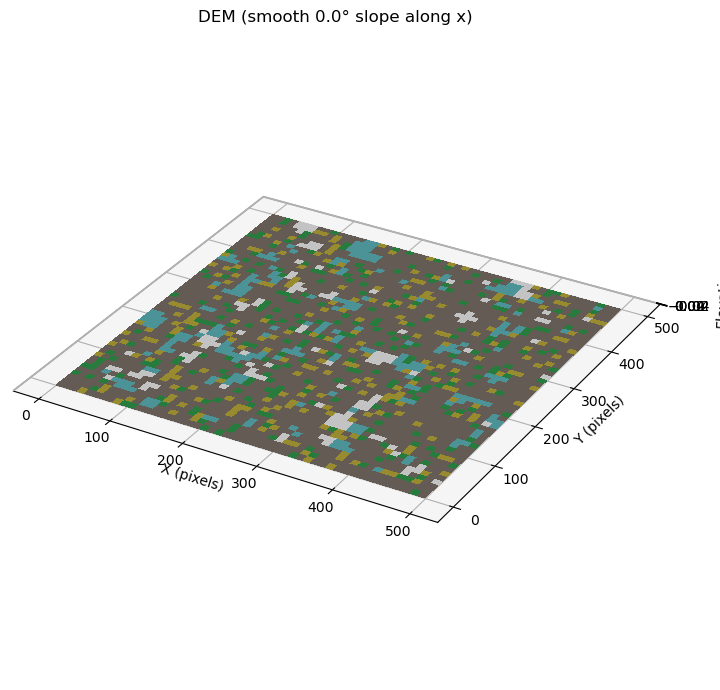

In [251]:
from pathlib import Path
import csv
import numpy as np
from scipy.ndimage import gaussian_filter  # not used in the angle version, but kept if you later switch back
import matplotlib.pyplot as plt

# ===================== USER SETTINGS =====================
# Base folder where your landcover CSV lives and where dem.npy will be saved
SCENARIO_NAME = "Snow_5_Algae_10_Moss_10_Lichen_10"

BASE_DIR = Path(
    r"G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover"
    fr"\TableB\{SCENARIO_NAME}"
)
# Input CSV (either lc_map.csv or landcover_table.csv)
LANDCOVER_CSV = BASE_DIR / "lc_map.csv"

# Output OBJ file
OBJ_NAME = f"{SCENARIO_NAME}_synthetic_dem.obj"

# DEM controls (angle-based smooth plane)
BASE_ELEV = 0.0          # elevation offset for the whole surface
SLOPE_ANGLE_DEG = 0.0   # exact slope angle in degrees
SLOPE_AXIS = "x"         # 'x' => increasing to the right; 'y' => increasing upward
PIXEL_SIZE = 1.0         # horizontal size of each pixel in OBJ units (e.g., 1 = one grid cell per unit)

# Preview controls
SHOW_3D = True

# OBJ output directory
Output = Path(r"C:\Users\hyou34\DART\user_data\simulations\Anttarctic Vegetation Dynamic\DART\Simulations\TableC\MultiGreenness")
# =========================================================

# Class dictionary and simple colors used for preview (RGB 0-1)
CLASS_NAMES = {0: "snow", 1: "rock", 2: "moss", 3: "algae", 4: "lichen"}
PALETTE = {
    0: (1.00, 1.00, 1.00),  # snow - white
    1: (0.51, 0.47, 0.43),  # rock - brown/gray
    2: (0.20, 0.63, 0.31),  # moss - green
    3: (0.39, 0.75, 0.78),  # algae - cyan
    4: (0.78, 0.71, 0.24),  # lichen - yellow
}

# ---------------- Robust Landcover Loader ----------------
def load_landcover(path: Path) -> np.ndarray:
    """
    Auto-detect landcover CSV format:
      - GRID: many columns (square/rectangular), each cell is a class id
      - TRIPLETS: rows of x,y,class (header allowed)
    Returns: uint8 2D array of class ids.
    """
    import pandas as pd

    # Try fast load with pandas
    try:
        df = pd.read_csv(path, header=None)
    except Exception:
        # Fallback parser for triplets
        return _read_triplets(path)

    # Heuristic: If there are more than 3 columns, this is a grid CSV
    if df.shape[1] > 3:
        arr = df.values.astype(np.uint8)
        return arr

    # If exactly 3 columns, treat as triplets (possibly with a header)
    if df.shape[1] == 3:
        # If the first row is non-numeric, re-read with header so columns can be named
        def _is_number(x):
            try:
                float(x)
                return True
            except Exception:
                return False

        first_row = df.iloc[0].tolist()
        if not all(_is_number(v) for v in first_row):
            df = pd.read_csv(path)  # with header row
            if df.shape[1] != 3:
                raise ValueError("Triplets CSV must have exactly 3 columns (x,y,class).")

        xs = df.iloc[:, 0].astype(int).to_numpy()
        ys = df.iloc[:, 1].astype(int).to_numpy()
        ts = df.iloc[:, 2].astype(int).to_numpy()

        h, w = ys.max() + 1, xs.max() + 1
        land = np.full((h, w), 1, dtype=np.uint8)  # default to 'rock' if missing
        land[ys, xs] = ts.astype(np.uint8)
        return land

    # Last resort: try the manual triplet reader
    return _read_triplets(path)


def _read_triplets(path: Path) -> np.ndarray:
    """
    Manual CSV loader for x,y,class triplets with optional header.
    """
    xs, ys, ts = [], [], []

    def _isnum(s):
        try:
            float(s)
            return True
        except Exception:
            return False

    with open(path, newline="") as f:
        rdr = csv.reader(f)
        first = next(rdr, None)
        # If the first row is numeric triplet, treat it as data; otherwise skip as header
        if first and len(first) >= 3 and _isnum(first[0]) and _isnum(first[1]) and _isnum(first[2]):
            xs.append(int(float(first[0])))
            ys.append(int(float(first[1])))
            ts.append(int(float(first[2])))

        for row in rdr:
            if len(row) < 3:
                continue
            xs.append(int(float(row[0])))
            ys.append(int(float(row[1])))
            ts.append(int(float(row[2])))

    h, w = max(ys) + 1, max(xs) + 1
    land = np.full((h, w), 1, dtype=np.uint8)  # default 'rock'
    land[ys, xs] = np.array(ts, dtype=np.uint8)
    return land


# ---------------- DEM Generator (Angle-based smooth plane) ----------------
def generate_dem_angle(land: np.ndarray, base_elev: float, angle_deg: float, axis: str = "x", pixel_size: float = 1.0) -> np.ndarray:
    """
    Generate a perfectly smooth planar DEM with a precise slope angle.

    Parameters
    ----------
    land : np.ndarray
        2D int array (H, W) of class IDs; only its shape is used here.
    base_elev : float
        Elevation offset added to the whole surface.
    angle_deg : float
        Target slope angle in degrees (e.g., 15.0).
    axis : str
        'x' => slope increases along columns (left->right).
        'y' => slope increases along rows (top->bottom).
    pixel_size : float
        Horizontal spacing between pixels in OBJ units. If each pixel is 1 m, set 1.0.

    Returns
    -------
    dem : np.ndarray
        Float DEM with shape (H, W), planar and ripple-free.
    """
    ny, nx = land.shape
    theta = np.deg2rad(angle_deg)
    # Elevation increment per pixel step along the slope axis
    step = np.tan(theta) * pixel_size

    if axis.lower() == "x":
        x = np.arange(nx, dtype=float)
        dem = base_elev + np.add.outer(np.zeros(ny, dtype=float), x * step)
    elif axis.lower() == "y":
        y = np.arange(ny, dtype=float)
        dem = base_elev + np.add.outer(y * step, np.zeros(nx, dtype=float))
    else:
        raise ValueError("axis must be 'x' or 'y'")
    return dem


# ---------------- OBJ Export ----------------
def write_obj(land: np.ndarray, dem: np.ndarray, out_path: Path):
    """
    Export a very simple OBJ:
      - Vertices laid on a regular grid: v x y z  (x=j, y=dem, z=i)
      - Faces only where the cell class matches the active group (two triangles per pixel)
      - Groups are written in the order: snow, moss, algae, lichen, rock (so rock is last)
    """
    rows, cols = land.shape
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with out_path.open("w") as f:
        f.write("# Synthetic DEM OBJ (smooth plane)\n")
        # Write vertices
        for i in range(rows):
            for j in range(cols):
                f.write(f"v {j} {dem[i, j]:.6f} {i}\n")

        # Write faces grouped by class for simple material assignment later if needed
        for cls in [0, 2, 3, 4, 1]:  # snow, moss, algae, lichen, rock
            f.write(f"g {CLASS_NAMES.get(cls, str(cls))}\n")
            for i in range(rows - 1):
                for j in range(cols - 1):
                    if land[i, j] != cls:
                        continue
                    v0 = i * cols + j + 1
                    v1 = v0 + 1
                    v2 = v0 + cols
                    v3 = v2 + 1
                    f.write(f"f {v0} {v2} {v3}\n")
                    f.write(f"f {v0} {v3} {v1}\n")


# ---------------- Preview ----------------
def show_dem_3d(land: np.ndarray, dem: np.ndarray, title: str = "DEM (smooth 15° slope)"):
    """
    Quick 3D preview using matplotlib. Colors are by landcover class.
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    ny, nx = land.shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))

    # Build RGB texture by class
    rgb = np.zeros((ny, nx, 3), dtype=float)
    for c, clr in PALETTE.items():
        rgb[land == c] = clr

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, dem, facecolors=rgb, linewidth=0, antialiased=False)
    ax.set_title(title)
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    ax.set_zlabel("Elevation")
    # Make Z a bit tighter so slope is visible
    ax.set_box_aspect((nx, ny, max(1, (dem.max() - dem.min()) * 0.25)))
    plt.tight_layout()
    plt.show()


# ---------------- RUN ----------------
if __name__ == "__main__":
    # 1) Load landcover (auto-detect grid vs triplets)
    land = load_landcover(LANDCOVER_CSV)

    # 2) Generate a perfectly smooth plane with an exact 15° slope
    dem = generate_dem_angle(
        land=land,
        base_elev=BASE_ELEV,
        angle_deg=SLOPE_ANGLE_DEG,
        axis=SLOPE_AXIS,
        pixel_size=PIXEL_SIZE,
    )

    # 3) Save outputs
    BASE_DIR.mkdir(parents=True, exist_ok=True)
    np.save(BASE_DIR / "dem.npy", dem)

    Output.mkdir(parents=True, exist_ok=True)
    write_obj(land, dem, Output / OBJ_NAME)
    print("✅ Outputs written:")
    print(f"   - DEM (npy): {BASE_DIR / 'dem.npy'}")
    print(f"   - OBJ:       {Output / OBJ_NAME}")

    # 4) Preview (optional)
    if SHOW_3D:
        title = f"DEM (smooth {SLOPE_ANGLE_DEG:.1f}° slope along {SLOPE_AXIS})"
        show_dem_3d(land, dem, title=title)


## Algae Loop

🧭 Using template landcover CSV:
G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_0\lc_map.csv
✅ [01] Saved dem.npy + Snow_0_Algae_1_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_1_Moss_0_Lichen_0


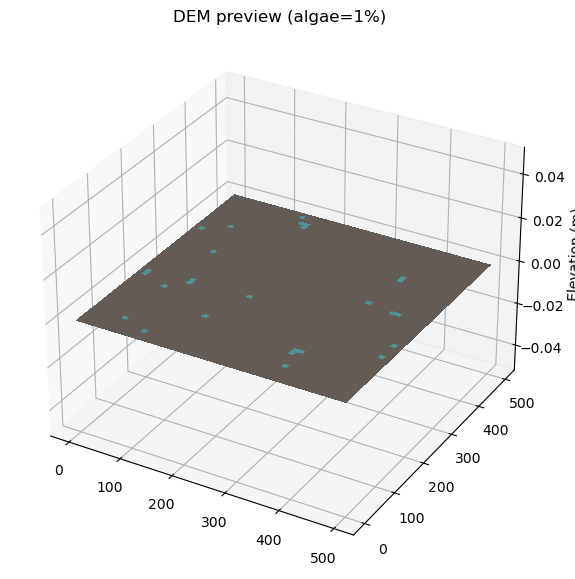

✅ [02] Saved dem.npy + Snow_0_Algae_2_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_2_Moss_0_Lichen_0
✅ [03] Saved dem.npy + Snow_0_Algae_3_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_3_Moss_0_Lichen_0
✅ [04] Saved dem.npy + Snow_0_Algae_4_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_4_Moss_0_Lichen_0
✅ [05] Saved dem.npy + Snow_0_Algae_5_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_5_Moss_0_Lichen_0
✅ [06] Saved dem.npy + Snow_0_Algae_6_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_N

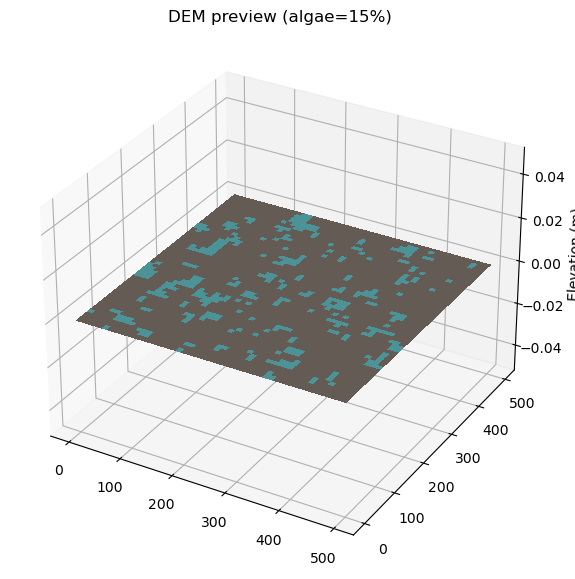

✅ [16] Saved dem.npy + Snow_0_Algae_16_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_16_Moss_0_Lichen_0
✅ [17] Saved dem.npy + Snow_0_Algae_17_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_17_Moss_0_Lichen_0
✅ [18] Saved dem.npy + Snow_0_Algae_18_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_18_Moss_0_Lichen_0
✅ [19] Saved dem.npy + Snow_0_Algae_19_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_19_Moss_0_Lichen_0
✅ [20] Saved dem.npy + Snow_0_Algae_20_Moss_0_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\An

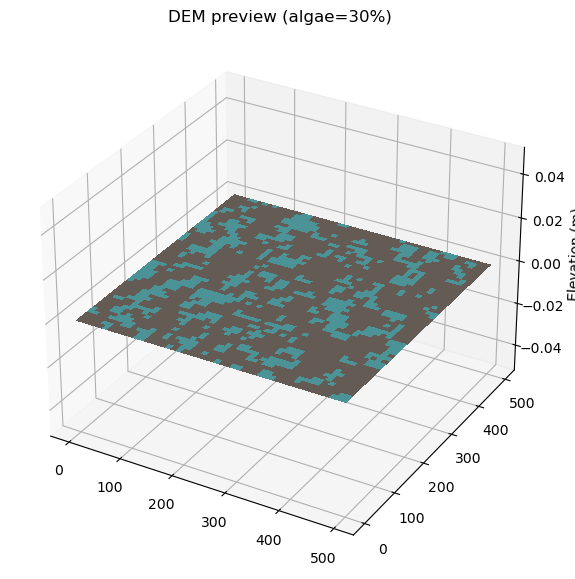


======== SUMMARY ========
Done. Success: 30 / 30
All cases succeeded 🎉


In [4]:
# %% [markdown]
# Batch-generate synthetic DEM + OBJ for algae = 1..30 (Jupyter-ready)

# %%
from pathlib import Path
import shutil, csv, json, sys, traceback
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from typing import Optional

# ========== USER SETTINGS ==========
ROOT = Path(r"G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA")
ALGAE_RANGE = range(1, 31)  # 1..30 inclusive
PREVIEW_STEPS = {1, 15, 30}  # which algae levels to preview in 3D

# DEM controls (same defaults as you provided)
USE_SLOPE       = False   # False => flat plane
BASE_ELEV       = 0.0
MAX_ALT_DIFF    = 20.0
SLOPE_FRACTION  = 0.6
NOISE_AMPLITUDE = 0.0     # 0 for perfectly plain ground
SMOOTH_SIGMA    = 6
RESCALE_TO_MAX  = True
SEED            = 43
# ===================================

CLASS_NAMES = {0:"snow",1:"rock",2:"moss",3:"algae",4:"lichen"}
PALETTE     = {0:(1,1,1),1:(0.51,0.47,0.43),2:(0.20,0.63,0.31),3:(0.39,0.75,0.78),4:(0.78,0.71,0.24)}

# ---------------- Robust Landcover Loader ----------------
def load_landcover(path: Path) -> np.ndarray:
    """
    Auto-detect landcover CSV format:
      - GRID: many columns (square/rectangular), each cell is a class id
      - TRIPLETS: rows of x,y,class (header allowed)
    Returns uint8 2D array of class ids.
    """
    import pandas as pd
    try:
        df = pd.read_csv(path, header=None)
    except Exception:
        # fallback to python csv as triplets
        return _read_triplets(path)

    # Heuristic: if columns > 3 or it's "wide", treat as GRID
    if df.shape[1] > 3:
        arr = df.values.astype(np.uint8)
        return arr

    # If exactly 3 columns and looks like integers → TRIPLETS
    if df.shape[1] == 3:
        # Check if it’s actually a header; if so, re-read with header=0
        def _is_numberish(x):
            try:
                float(x); return True
            except Exception:
                return False
        if not (_is_numberish(df.iloc[0,0]) and _is_numberish(df.iloc[0,1]) and _is_numberish(df.iloc[0,2])):
            df = pd.read_csv(path)  # with header
            if df.shape[1] != 3:
                raise ValueError("Triplets CSV must have exactly 3 columns (x,y,class).")
        xs = df.iloc[:,0].astype(int).to_numpy()
        ys = df.iloc[:,1].astype(int).to_numpy()
        ts = df.iloc[:,2].astype(int).to_numpy()
        h, w = ys.max()+1, xs.max()+1
        land = np.full((h, w), 1, dtype=np.uint8)
        land[ys, xs] = ts.astype(np.uint8)
        return land

    # Fallback: parse as triplets with csv
    return _read_triplets(path)

def _read_triplets(path: Path) -> np.ndarray:
    xs, ys, ts = [], [], []
    with open(path, newline="") as f:
        rdr = csv.reader(f)
        first = next(rdr, None)

        def _isnum(s):
            try: float(s); return True
            except: return False

        if first and len(first) >= 3 and _isnum(first[0]) and _isnum(first[1]) and _isnum(first[2]):
            xs.append(int(float(first[0]))); ys.append(int(float(first[1]))); ts.append(int(float(first[2])))

        for row in rdr:
            if len(row) < 3: 
                continue
            xs.append(int(float(row[0]))); ys.append(int(float(row[1]))); ts.append(int(float(row[2])))
    h, w = max(ys)+1, max(xs)+1
    land = np.full((h, w), 1, dtype=np.uint8)
    land[ys, xs] = np.array(ts, dtype=np.uint8)
    return land

# ---------------- DEM Generator ----------------
def generate_dem(land, use_slope, base_elev, max_alt_diff, slope_fraction,
                 noise_amplitude, smooth_sigma, rescale, seed):
    ny, nx = land.shape
    rng = np.random.default_rng(seed)
    dem = np.full((ny,nx), base_elev, float)

    if use_slope:
        sx = np.linspace(0, max_alt_diff*slope_fraction, nx)
        dem += np.add.outer(np.zeros(ny), sx)

    if noise_amplitude > 0:
        noise = rng.random((ny,nx)) - 0.5
        if smooth_sigma > 0:
            noise = gaussian_filter(noise, smooth_sigma)
        # normalize to [-0.5, 0.5]
        nmin, nmax = noise.min(), noise.max()
        if nmax > nmin:
            noise = (noise - nmin) / (nmax - nmin) - 0.5
        dem += noise * max_alt_diff * noise_amplitude

    if rescale:
        mn, mx = dem.min(), dem.max()
        if mx > mn:
            dem = (dem - mn) / (mx - mn) * max_alt_diff + base_elev
        else:
            dem[:] = base_elev  # perfectly flat
    return dem

# ---------------- OBJ Export ----------------
def write_obj(land, dem, out_path: Path):
    rows, cols = land.shape
    with out_path.open("w", encoding="utf-8") as f:
        f.write("# Synthetic DEM OBJ\n")
        # vertices
        for i in range(rows):
            for j in range(cols):
                f.write(f"v {j} {dem[i,j]:.6f} {i}\n")
        # groups by class (keep your order)
        for cls in [0,2,3,4,1]:
            f.write(f"g {CLASS_NAMES.get(cls, cls)}\n")
            for i in range(rows-1):
                for j in range(cols-1):
                    if land[i,j] != cls: 
                        continue
                    v0=i*cols+j+1; v1=v0+1; v2=v0+cols; v3=v2+1
                    f.write(f"f {v0} {v2} {v3}\n")
                    f.write(f"f {v0} {v3} {v1}\n")

# ---------------- Preview ----------------
def show_dem_3d(land, dem, title="DEM preview"):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    ny,nx = land.shape
    X,Y=np.meshgrid(range(nx),range(ny))
    rgb=np.zeros((ny,nx,3))
    for c,clr in PALETTE.items():
        rgb[land==c]=clr
    fig=plt.figure(figsize=(10,7))
    ax=fig.add_subplot(111,projection="3d")
    ax.plot_surface(X,Y,dem,facecolors=rgb,linewidth=0,antialiased=False)
    ax.set_title(title)
    ax.set_zlabel("Elevation (m)")
    plt.show()

# ---------------- Helpers ----------------
def discover_template_csv(root: Path) -> Optional[Path]:
    """
    Find any lc_map.csv (or landcover_table.csv) under ROOT to use as a template
    for cases where the target folder has none.
    """
    p = root / "lc_map.csv"
    if p.exists():
        return p
    
    candidates = list(root.glob("**/lc_map.csv"))
    if candidates:
        return candidates[0]

    candidates = list(root.glob("**/landcover_table.csv"))
    if candidates:
        return candidates[0]

    return None

# ---------------- Main Loop ----------------
template_csv = discover_template_csv(ROOT)
if template_csv is None:
    print("⚠️ No template landcover CSV found under ROOT. "
          "Make sure each target folder has 'lc_map.csv' or place one in ROOT.")
else:
    print(f"🧭 Using template landcover CSV:\n{template_csv}")

success, failed = [], []

for algae in ALGAE_RANGE:
    try:
        folder_name = f"Snow_0_Algae_{algae}_Moss_0_Lichen_0"
        base_dir = ROOT / folder_name
        base_dir.mkdir(parents=True, exist_ok=True)

        lc_csv = base_dir / "lc_map.csv"
        if not lc_csv.exists():
            if template_csv is not None:
                shutil.copy(template_csv, lc_csv)
                print(f"📄 Copied template lc_map.csv → {lc_csv}")
            else:
                print(f"⏭️  Skipping {folder_name}: missing lc_map.csv and no template available.")
                failed.append((algae, "no landcover csv"))
                continue

        # Load landcover
        land = load_landcover(lc_csv)

        # Generate DEM
        dem = generate_dem(
            land,
            USE_SLOPE, BASE_ELEV, MAX_ALT_DIFF, SLOPE_FRACTION,
            NOISE_AMPLITUDE, SMOOTH_SIGMA, RESCALE_TO_MAX, SEED
        )

        # Assert flatness if expected
        if not USE_SLOPE and NOISE_AMPLITUDE == 0.0:
            # Allow floating noise in comparisons due to dtype—use ptp close to 0
            if not np.isclose(np.ptp(dem), 0.0, atol=1e-12):
                raise AssertionError("DEM is not flat—check parameters.")

        # Save outputs
        np.save(base_dir / "dem.npy", dem)
        obj_name = f"{folder_name}_synthetic_dem.obj"
        Output = Path(r"C:\Users\hyou34\DART\user_data\simulations\Anttarctic_Vegetation_Dynamic\DART\Simulations\TableA\PureAlgae\input")
        write_obj(land, dem, Output / obj_name)
        #write_obj(land, dem, base_dir / obj_name)

        print(f"✅ [{algae:02d}] Saved dem.npy + {obj_name} in:\n   {base_dir}")
        success.append(algae)

        # Preview some steps
        if algae in PREVIEW_STEPS:
            show_dem_3d(land, dem, title=f"DEM preview (algae={algae}%)")

    except Exception as e:
        print(f"❌ [{algae:02d}] Failed: {e}")
        traceback.print_exc(limit=1)
        failed.append((algae, str(e)))

print("\n======== SUMMARY ========")
print(f"Done. Success: {len(success)} / {len(ALGAE_RANGE)}")
if failed:
    print("Failed cases:", failed)
else:
    print("All cases succeeded 🎉")

## Moss Loop

🧭 Using template landcover CSV:
G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_0\lc_map.csv
✅ [01] Saved dem.npy + Snow_0_Algae_0_Moss_1_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_1_Lichen_0


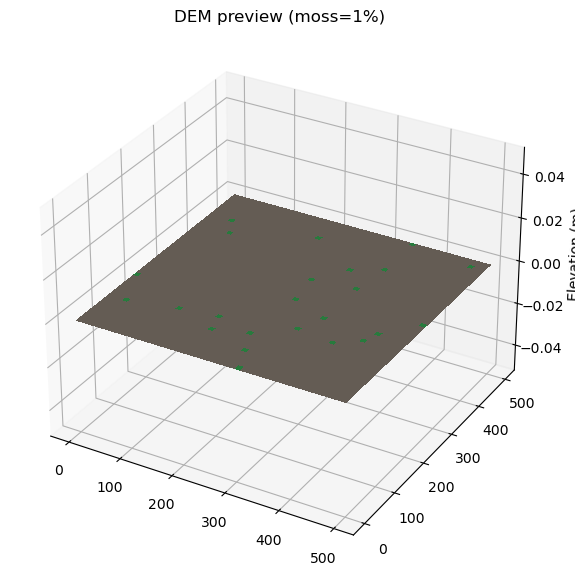

✅ [02] Saved dem.npy + Snow_0_Algae_0_Moss_2_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_2_Lichen_0
✅ [03] Saved dem.npy + Snow_0_Algae_0_Moss_3_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_3_Lichen_0
✅ [04] Saved dem.npy + Snow_0_Algae_0_Moss_4_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_4_Lichen_0
✅ [05] Saved dem.npy + Snow_0_Algae_0_Moss_5_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_5_Lichen_0
✅ [06] Saved dem.npy + Snow_0_Algae_0_Moss_6_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_N

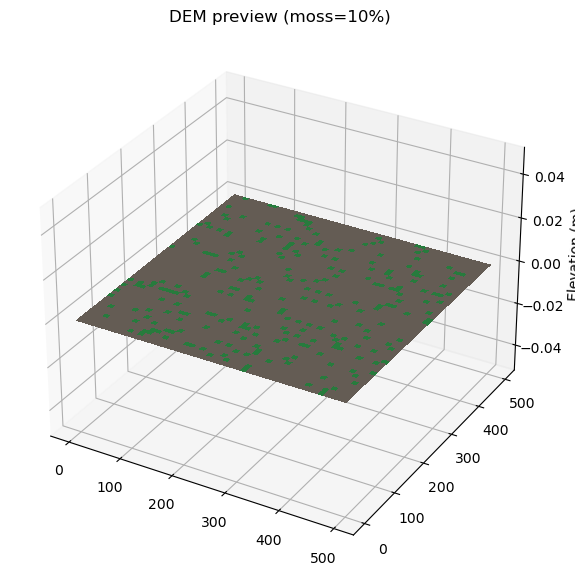

✅ [11] Saved dem.npy + Snow_0_Algae_0_Moss_11_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_11_Lichen_0
✅ [12] Saved dem.npy + Snow_0_Algae_0_Moss_12_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_12_Lichen_0
✅ [13] Saved dem.npy + Snow_0_Algae_0_Moss_13_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_13_Lichen_0
✅ [14] Saved dem.npy + Snow_0_Algae_0_Moss_14_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_14_Lichen_0
✅ [15] Saved dem.npy + Snow_0_Algae_0_Moss_15_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\An

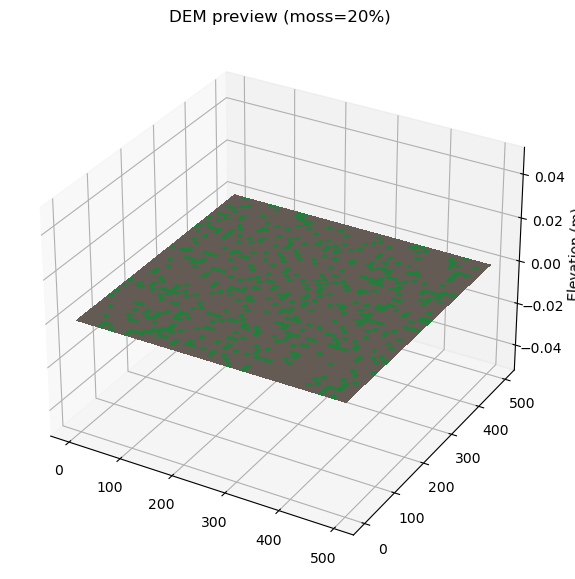

✅ [21] Saved dem.npy + Snow_0_Algae_0_Moss_21_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_21_Lichen_0
✅ [22] Saved dem.npy + Snow_0_Algae_0_Moss_22_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_22_Lichen_0
✅ [23] Saved dem.npy + Snow_0_Algae_0_Moss_23_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_23_Lichen_0
✅ [24] Saved dem.npy + Snow_0_Algae_0_Moss_24_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_24_Lichen_0
✅ [25] Saved dem.npy + Snow_0_Algae_0_Moss_25_Lichen_0_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\An

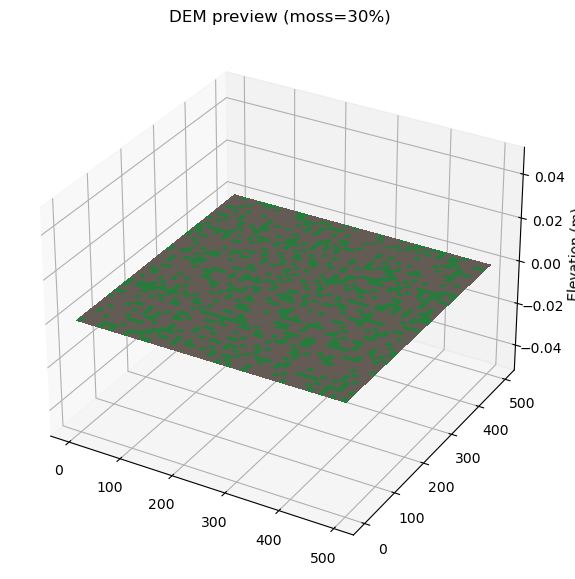


======== SUMMARY ========
Done. Success: 30 / 30
All cases succeeded 🎉


In [6]:
# %% [markdown]
# Batch-generate synthetic DEM + OBJ for moss = 1..30 (Jupyter-ready)

# %%
from pathlib import Path
import shutil, csv, json, sys, traceback
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from typing import Optional

# ========== USER SETTINGS ==========
ROOT = Path(r"G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA")
MOSS_RANGE = range(1, 31)        # 1..30 inclusive (percent)
PREVIEW_STEPS = {1, 10, 20, 30}  # which moss levels to preview in 3D

# DEM controls (same defaults as before)
USE_SLOPE       = False   # False => flat plane
BASE_ELEV       = 0.0
MAX_ALT_DIFF    = 20.0
SLOPE_FRACTION  = 0.6
NOISE_AMPLITUDE = 0.0     # 0 for perfectly plain ground
SMOOTH_SIGMA    = 6
RESCALE_TO_MAX  = True
SEED            = 43
# ===================================

CLASS_NAMES = {0:"snow",1:"rock",2:"moss",3:"algae",4:"lichen"}
PALETTE     = {0:(1,1,1),1:(0.51,0.47,0.43),2:(0.20,0.63,0.31),3:(0.39,0.75,0.78),4:(0.78,0.71,0.24)}

# ---------------- Robust Landcover Loader ----------------
def load_landcover(path: Path) -> np.ndarray:
    """
    Auto-detect landcover CSV format:
      - GRID: many columns (square/rectangular), each cell is a class id
      - TRIPLETS: rows of x,y,class (header allowed)
    Returns uint8 2D array of class ids.
    """
    import pandas as pd
    try:
        df = pd.read_csv(path, header=None)
    except Exception:
        # fallback to python csv as triplets
        return _read_triplets(path)

    # Heuristic: if columns > 3 or it's "wide", treat as GRID
    if df.shape[1] > 3:
        arr = df.values.astype(np.uint8)
        return arr

    # If exactly 3 columns and looks like integers → TRIPLETS
    if df.shape[1] == 3:
        def _is_numberish(x):
            try:
                float(x); return True
            except Exception:
                return False
        if not (_is_numberish(df.iloc[0,0]) and _is_numberish(df.iloc[0,1]) and _is_numberish(df.iloc[0,2])):
            df = pd.read_csv(path)  # with header
            if df.shape[1] != 3:
                raise ValueError("Triplets CSV must have exactly 3 columns (x,y,class).")
        xs = df.iloc[:,0].astype(int).to_numpy()
        ys = df.iloc[:,1].astype(int).to_numpy()
        ts = df.iloc[:,2].astype(int).to_numpy()
        h, w = ys.max()+1, xs.max()+1
        land = np.full((h, w), 1, dtype=np.uint8)
        land[ys, xs] = ts.astype(np.uint8)
        return land

    # Fallback: parse as triplets with csv
    return _read_triplets(path)

def _read_triplets(path: Path) -> np.ndarray:
    xs, ys, ts = [], [], []
    with open(path, newline="") as f:
        rdr = csv.reader(f)
        first = next(rdr, None)

        def _isnum(s):
            try: float(s); return True
            except: return False

        if first and len(first) >= 3 and _isnum(first[0]) and _isnum(first[1]) and _isnum(first[2]):
            xs.append(int(float(first[0]))); ys.append(int(float(first[1]))); ts.append(int(float(first[2])))

        for row in rdr:
            if len(row) < 3: 
                continue
            xs.append(int(float(row[0]))); ys.append(int(float(row[1]))); ts.append(int(float(row[2])))
    h, w = max(ys)+1, max(xs)+1
    land = np.full((h, w), 1, dtype=np.uint8)
    land[ys, xs] = np.array(ts, dtype=np.uint8)
    return land

# ---------------- DEM Generator ----------------
def generate_dem(land, use_slope, base_elev, max_alt_diff, slope_fraction,
                 noise_amplitude, smooth_sigma, rescale, seed):
    ny, nx = land.shape
    rng = np.random.default_rng(seed)
    dem = np.full((ny,nx), base_elev, float)

    if use_slope:
        sx = np.linspace(0, max_alt_diff*slope_fraction, nx)
        dem += np.add.outer(np.zeros(ny), sx)

    if noise_amplitude > 0:
        noise = rng.random((ny,nx)) - 0.5
        if smooth_sigma > 0:
            noise = gaussian_filter(noise, smooth_sigma)
        # normalize to [-0.5, 0.5]
        nmin, nmax = noise.min(), noise.max()
        if nmax > nmin:
            noise = (noise - nmin) / (nmax - nmin) - 0.5
        dem += noise * max_alt_diff * noise_amplitude

    if rescale:
        mn, mx = dem.min(), dem.max()
        if mx > mn:
            dem = (dem - mn) / (mx - mn) * max_alt_diff + base_elev
        else:
            dem[:] = base_elev  # perfectly flat
    return dem

# ---------------- OBJ Export ----------------
def write_obj(land, dem, out_path: Path):
    rows, cols = land.shape
    with out_path.open("w", encoding="utf-8") as f:
        f.write("# Synthetic DEM OBJ\n")
        # vertices
        for i in range(rows):
            for j in range(cols):
                f.write(f"v {j} {dem[i,j]:.6f} {i}\n")
        # groups by class (keep your order)
        for cls in [0,2,3,4,1]:
            f.write(f"g {CLASS_NAMES.get(cls, cls)}\n")
            for i in range(rows-1):
                for j in range(cols-1):
                    if land[i,j] != cls: 
                        continue
                    v0=i*cols+j+1; v1=v0+1; v2=v0+cols; v3=v2+1
                    f.write(f"f {v0} {v2} {v3}\n")
                    f.write(f"f {v0} {v3} {v1}\n")

# ---------------- Preview ----------------
def show_dem_3d(land, dem, title="DEM preview"):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    ny,nx = land.shape
    X,Y=np.meshgrid(range(nx),range(ny))
    rgb=np.zeros((ny,nx,3))
    for c,clr in PALETTE.items():
        rgb[land==c]=clr
    fig=plt.figure(figsize=(10,7))
    ax=fig.add_subplot(111,projection="3d")
    ax.plot_surface(X,Y,dem,facecolors=rgb,linewidth=0,antialiased=False)
    ax.set_title(title)
    ax.set_zlabel("Elevation (m)")
    plt.show()

# ---------------- Helpers ----------------
def discover_template_csv(root: Path) -> Optional[Path]:
    """
    Find any lc_map.csv (or landcover_table.csv) under ROOT to use as a template
    for cases where the target folder has none.
    """
    p = root / "lc_map.csv"
    if p.exists():
        return p
    
    candidates = list(root.glob("**/lc_map.csv"))
    if candidates:
        return candidates[0]

    candidates = list(root.glob("**/landcover_table.csv"))
    if candidates:
        return candidates[0]

    return None

# ---------------- Main Loop ----------------
template_csv = discover_template_csv(ROOT)
if template_csv is None:
    print("⚠️ No template landcover CSV found under ROOT. "
          "Make sure each target folder has 'lc_map.csv' or place one in ROOT.")
else:
    print(f"🧭 Using template landcover CSV:\n{template_csv}")

success, failed = [], []

for moss in MOSS_RANGE:
    try:
        # Folder tag mirrors your integer input percentages (no decimals)
        folder_name = f"Snow_0_Algae_0_Moss_{moss}_Lichen_0"
        base_dir = ROOT / folder_name
        base_dir.mkdir(parents=True, exist_ok=True)

        lc_csv = base_dir / "lc_map.csv"
        if not lc_csv.exists():
            if template_csv is not None:
                shutil.copy(template_csv, lc_csv)
                print(f"📄 Copied template lc_map.csv → {lc_csv}")
            else:
                print(f"⏭️  Skipping {folder_name}: missing lc_map.csv and no template available.")
                failed.append((moss, "no landcover csv"))
                continue

        # Load landcover
        land = load_landcover(lc_csv)

        # Generate DEM
        dem = generate_dem(
            land,
            USE_SLOPE, BASE_ELEV, MAX_ALT_DIFF, SLOPE_FRACTION,
            NOISE_AMPLITUDE, SMOOTH_SIGMA, RESCALE_TO_MAX, SEED
        )

        # Assert flatness if expected
        if not USE_SLOPE and NOISE_AMPLITUDE == 0.0:
            if not np.isclose(np.ptp(dem), 0.0, atol=1e-12):
                raise AssertionError("DEM is not flat—check parameters.")

        # Save outputs
        np.save(base_dir / "dem.npy", dem)

        # Write OBJ to your DART sim input folder (adjust if needed)
        obj_name = f"{folder_name}_synthetic_dem.obj"
        Output = Path(r"C:\Users\hyou34\DART\user_data\simulations\Anttarctic_Vegetation_Dynamic\DART\Simulations\TableA\PureAlgae\input")
        write_obj(land, dem, Output / obj_name)
        # Or save next to the folder:
        # write_obj(land, dem, base_dir / obj_name)

        print(f"✅ [{moss:02d}] Saved dem.npy + {obj_name} in:\n   {base_dir}")
        success.append(moss)

        # Preview some steps
        if moss in PREVIEW_STEPS:
            show_dem_3d(land, dem, title=f"DEM preview (moss={moss}%)")

    except Exception as e:
        print(f"❌ [{moss:02d}] Failed: {e}")
        traceback.print_exc(limit=1)
        failed.append((moss, str(e)))

print("\n======== SUMMARY ========")
print(f"Done. Success: {len(success)} / {len(MOSS_RANGE)}")
if failed:
    print("Failed cases:", failed)
else:
    print("All cases succeeded 🎉")

## Lichen Loop

🧭 Using template landcover CSV:
G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_0\lc_map.csv
✅ [01] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_1_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_1


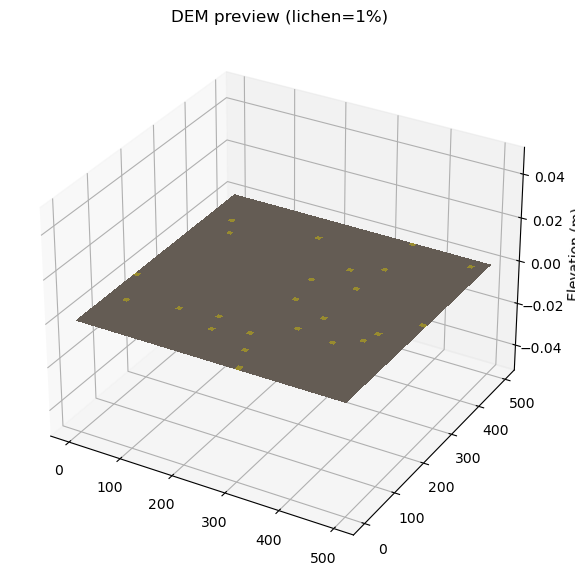

✅ [02] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_2_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_2
✅ [03] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_3_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_3
✅ [04] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_4_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_4
✅ [05] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_5_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_5
✅ [06] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_6_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_N

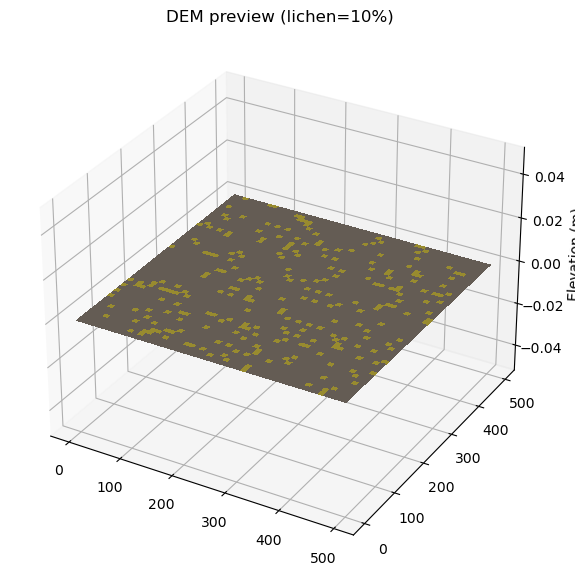

✅ [11] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_11_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_11
✅ [12] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_12_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_12
✅ [13] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_13_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_13
✅ [14] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_14_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_14
✅ [15] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_15_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\An

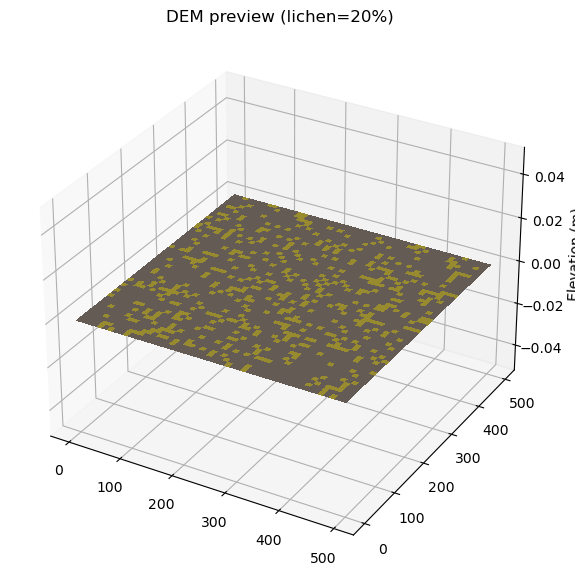

✅ [21] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_21_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_21
✅ [22] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_22_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_22
✅ [23] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_23_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_23
✅ [24] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_24_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA\Snow_0_Algae_0_Moss_0_Lichen_24
✅ [25] Saved dem.npy + Snow_0_Algae_0_Moss_0_Lichen_25_synthetic_dem.obj in:
   G:\Hangkai\Anttarctic Vegetation Dynamic\DART\An

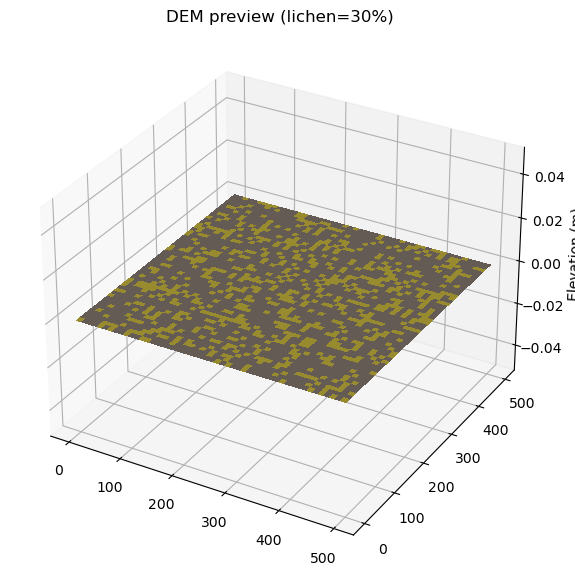


======== SUMMARY ========
Done. Success: 30 / 30
All cases succeeded 🎉


In [25]:
# %% [markdown]
# Batch-generate synthetic DEM + OBJ for lichen = 1..30 (Jupyter-ready)

# %%
from pathlib import Path
import shutil, csv, json, sys, traceback
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from typing import Optional

# ========== USER SETTINGS ==========
ROOT = Path(r"G:\Hangkai\Anttarctic Vegetation Dynamic\DART\Antarctic_NDVI_all\Antarctic_NDVI_all\Data\LandCover\TableA")
LICHEN_RANGE = range(1, 31)      # 1..30 inclusive (percent)
PREVIEW_STEPS = {1, 10, 20, 30}  # which lichen levels to preview in 3D

# DEM controls (same defaults as before)
USE_SLOPE       = False   # False => flat plane
BASE_ELEV       = 0.0
MAX_ALT_DIFF    = 20.0
SLOPE_FRACTION  = 0.6
NOISE_AMPLITUDE = 0.0     # 0 for perfectly plain ground
SMOOTH_SIGMA    = 6
RESCALE_TO_MAX  = True
SEED            = 43
# ===================================

CLASS_NAMES = {0:"snow",1:"rock",2:"moss",3:"algae",4:"lichen"}
PALETTE     = {0:(1,1,1),1:(0.51,0.47,0.43),2:(0.20,0.63,0.31),3:(0.39,0.75,0.78),4:(0.78,0.71,0.24)}

# ---------------- Robust Landcover Loader ----------------
def load_landcover(path: Path) -> np.ndarray:
    """
    Auto-detect landcover CSV format:
      - GRID: many columns (square/rectangular), each cell is a class id
      - TRIPLETS: rows of x,y,class (header allowed)
    Returns uint8 2D array of class ids.
    """
    import pandas as pd
    try:
        df = pd.read_csv(path, header=None)
    except Exception:
        # fallback to python csv as triplets
        return _read_triplets(path)

    # Heuristic: if columns > 3 or it's "wide", treat as GRID
    if df.shape[1] > 3:
        arr = df.values.astype(np.uint8)
        return arr

    # If exactly 3 columns and looks like integers → TRIPLETS
    if df.shape[1] == 3:
        def _is_numberish(x):
            try:
                float(x); return True
            except Exception:
                return False
        if not (_is_numberish(df.iloc[0,0]) and _is_numberish(df.iloc[0,1]) and _is_numberish(df.iloc[0,2])):
            df = pd.read_csv(path)  # with header
            if df.shape[1] != 3:
                raise ValueError("Triplets CSV must have exactly 3 columns (x,y,class).")
        xs = df.iloc[:,0].astype(int).to_numpy()
        ys = df.iloc[:,1].astype(int).to_numpy()
        ts = df.iloc[:,2].astype(int).to_numpy()
        h, w = ys.max()+1, xs.max()+1
        land = np.full((h, w), 1, dtype=np.uint8)
        land[ys, xs] = ts.astype(np.uint8)
        return land

    # Fallback: parse as triplets with csv
    return _read_triplets(path)

def _read_triplets(path: Path) -> np.ndarray:
    xs, ys, ts = [], [], []
    with open(path, newline="") as f:
        rdr = csv.reader(f)
        first = next(rdr, None)

        def _isnum(s):
            try: float(s); return True
            except: return False

        if first and len(first) >= 3 and _isnum(first[0]) and _isnum(first[1]) and _isnum(first[2]):
            xs.append(int(float(first[0]))); ys.append(int(float(first[1]))); ts.append(int(float(first[2])))

        for row in rdr:
            if len(row) < 3: 
                continue
            xs.append(int(float(row[0]))); ys.append(int(float(row[1]))); ts.append(int(float(row[2])))
    h, w = max(ys)+1, max(xs)+1
    land = np.full((h, w), 1, dtype=np.uint8)
    land[ys, xs] = np.array(ts, dtype=np.uint8)
    return land

# ---------------- DEM Generator ----------------
def generate_dem(land, use_slope, base_elev, max_alt_diff, slope_fraction,
                 noise_amplitude, smooth_sigma, rescale, seed):
    ny, nx = land.shape
    rng = np.random.default_rng(seed)
    dem = np.full((ny,nx), base_elev, float)

    if use_slope:
        sx = np.linspace(0, max_alt_diff*slope_fraction, nx)
        dem += np.add.outer(np.zeros(ny), sx)

    if noise_amplitude > 0:
        noise = rng.random((ny,nx)) - 0.5
        if smooth_sigma > 0:
            noise = gaussian_filter(noise, smooth_sigma)
        # normalize to [-0.5, 0.5]
        nmin, nmax = noise.min(), noise.max()
        if nmax > nmin:
            noise = (noise - nmin) / (nmax - nmin) - 0.5
        dem += noise * max_alt_diff * noise_amplitude

    if rescale:
        mn, mx = dem.min(), dem.max()
        if mx > mn:
            dem = (dem - mn) / (mx - mn) * max_alt_diff + base_elev
        else:
            dem[:] = base_elev  # perfectly flat
    return dem

# ---------------- OBJ Export ----------------
def write_obj(land, dem, out_path: Path):
    rows, cols = land.shape
    with out_path.open("w", encoding="utf-8") as f:
        f.write("# Synthetic DEM OBJ\n")
        # vertices
        for i in range(rows):
            for j in range(cols):
                f.write(f"v {j} {dem[i,j]:.6f} {i}\n")
        # groups by class (keep your order)
        for cls in [0,2,3,4,1]:
            f.write(f"g {CLASS_NAMES.get(cls, cls)}\n")
            for i in range(rows-1):
                for j in range(cols-1):
                    if land[i,j] != cls: 
                        continue
                    v0=i*cols+j+1; v1=v0+1; v2=v0+cols; v3=v2+1
                    f.write(f"f {v0} {v2} {v3}\n")
                    f.write(f"f {v0} {v3} {v1}\n")

# ---------------- Preview ----------------
def show_dem_3d(land, dem, title="DEM preview"):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    ny,nx = land.shape
    X,Y=np.meshgrid(range(nx),range(ny))
    rgb=np.zeros((ny,nx,3))
    for c,clr in PALETTE.items():
        rgb[land==c]=clr
    fig=plt.figure(figsize=(10,7))
    ax=fig.add_subplot(111,projection="3d")
    ax.plot_surface(X,Y,dem,facecolors=rgb,linewidth=0,antialiased=False)
    ax.set_title(title)
    ax.set_zlabel("Elevation (m)")
    plt.show()

# ---------------- Helpers ----------------
def discover_template_csv(root: Path) -> Optional[Path]:
    """
    Find any lc_map.csv (or landcover_table.csv) under ROOT to use as a template
    for cases where the target folder has none.
    """
    p = root / "lc_map.csv"
    if p.exists():
        return p
    
    candidates = list(root.glob("**/lc_map.csv"))
    if candidates:
        return candidates[0]

    candidates = list(root.glob("**/landcover_table.csv"))
    if candidates:
        return candidates[0]

    return None

# ---------------- Main Loop ----------------
template_csv = discover_template_csv(ROOT)
if template_csv is None:
    print("⚠️ No template landcover CSV found under ROOT. "
          "Make sure each target folder has 'lc_map.csv' or place one in ROOT.")
else:
    print(f"🧭 Using template landcover CSV:\n{template_csv}")

success, failed = [], []

for lichen in LICHEN_RANGE:
    try:
        # Folder tag mirrors your integer input percentages (no decimals)
        folder_name = f"Snow_0_Algae_0_Moss_0_Lichen_{lichen}"
        base_dir = ROOT / folder_name
        base_dir.mkdir(parents=True, exist_ok=True)

        lc_csv = base_dir / "lc_map.csv"
        if not lc_csv.exists():
            if template_csv is not None:
                shutil.copy(template_csv, lc_csv)
                print(f"📄 Copied template lc_map.csv → {lc_csv}")
            else:
                print(f"⏭️  Skipping {folder_name}: missing lc_map.csv and no template available.")
                failed.append((lichen, "no landcover csv"))
                continue

        # Load landcover
        land = load_landcover(lc_csv)

        # Generate DEM
        dem = generate_dem(
            land,
            USE_SLOPE, BASE_ELEV, MAX_ALT_DIFF, SLOPE_FRACTION,
            NOISE_AMPLITUDE, SMOOTH_SIGMA, RESCALE_TO_MAX, SEED
        )

        # Assert flatness if expected
        if not USE_SLOPE and NOISE_AMPLITUDE == 0.0:
            if not np.isclose(np.ptp(dem), 0.0, atol=1e-12):
                raise AssertionError("DEM is not flat—check parameters.")

        # Save outputs
        np.save(base_dir / "dem.npy", dem)

        # Write OBJ to your DART sim input folder (adjust if needed)
        obj_name = f"{folder_name}_synthetic_dem.obj"
        Output = Path(r"C:\Users\hyou34\DART\user_data\simulations\Anttarctic_Vegetation_Dynamic\DART\Simulations\TableA\PureAlgae\input")
        Output.mkdir(parents=True, exist_ok=True)
        write_obj(land, dem, Output / obj_name)
        # Or save next to the folder:
        # write_obj(land, dem, base_dir / obj_name)

        print(f"✅ [{lichen:02d}] Saved dem.npy + {obj_name} in:\n   {base_dir}")
        success.append(lichen)

        # Preview some steps
        if lichen in PREVIEW_STEPS:
            show_dem_3d(land, dem, title=f"DEM preview (lichen={lichen}%)")

    except Exception as e:
        print(f"❌ [{lichen:02d}] Failed: {e}")
        traceback.print_exc(limit=1)
        failed.append((lichen, str(e)))

print("\n======== SUMMARY ========")
print(f"Done. Success: {len(success)} / {len(LICHEN_RANGE)}")
if failed:
    print("Failed cases:", failed)
else:
    print("All cases succeeded 🎉")